# 02 — Leakage entfernen und Daten aufteilen

**Etappe 6.** Am Ende dieses Notebooks liegen drei Teilmengen unter
`data/processed/`, und es ist schriftlich begründet, welche Spalten warum
entfernt wurden.

Zwei Dinge passieren hier, und die Reihenfolge ist nicht beliebig: **erst** die
Spalten entfernen, die zum Vorhersagezeitpunkt gar nicht vorliegen, **dann**
aufteilen. Umgekehrt würde man Leakage in alle drei Teilmengen tragen.

Der Befund aus Notebook 01 ist die Grundlage: jede Zeile trägt eine eigene
`product_id`, es gibt keinen Zeitstempel. Deshalb darf zeilenweise aufgeteilt
werden, geschichtet nach der Zielklasse.

In [1]:
import pandas as pd

from src.data.load import load_raw_data
from src.data.split import (
    entferne_leakage_und_kennungen,
    schreibe_teilmengen,
    split_data,
    uebersicht,
)
from src.data.validate import load_params, validate_dataframe
from src.utils.plotting import FARBEN, nur_y_gitter, setze_stil, speichere

import matplotlib.pyplot as plt

setze_stil()
params = load_params()
ziel = params["data"]["target"]
seed = params["seed"]

roh = load_raw_data()
validate_dataframe(roh).raise_if_invalid()
print(f"Rohdaten: {roh.shape[0]} Zeilen x {roh.shape[1]} Spalten")

Rohdaten: 10000 Zeilen x 14 Spalten


## 1 Welche Spalten fliegen raus — und warum

Zwei Gruppen, aus zwei verschiedenen Gründen.

**Ursachenspalten** `TWF`, `HDF`, `PWF`, `OSF`, `RNF` — sie beschreiben, *warum*
eine Maschine ausgefallen ist. Diese Information entsteht gemeinsam mit dem
Ausfall. Zu dem Zeitpunkt, an dem das Modell im Betrieb gefragt wird, existiert
sie noch nicht. Ein Modell mit diesen Spalten sagt den Ausfall nicht vorher, es
liest ihn ab.

**Kennungen** `udi` und `product_id` — laufende Nummern ohne fachlichen Gehalt.
Sie sind je Zeile eindeutig, ein Baum könnte sich daran festhalten und die
Trainingsdaten schlicht auswendig lernen.

In [2]:
merkmale = entferne_leakage_und_kennungen(roh, params)

entfernt = [s for s in roh.columns if s not in merkmale.columns]
print("entfernt   :", ", ".join(entfernt))
print("verbleibend:", ", ".join(merkmale.columns))
print(f"\n{roh.shape[1]} Spalten -> {merkmale.shape[1]} Spalten "
      f"(davon {merkmale.shape[1] - 1} Merkmale + Zielgröße)")

entfernt   : udi, product_id, twf, hdf, pwf, osf, rnf
verbleibend: type, air_temperature_k, process_temperature_k, rotational_speed_rpm, torque_nm, tool_wear_min, machine_failure

14 Spalten -> 7 Spalten (davon 6 Merkmale + Zielgröße)


Von 14 Spalten bleiben 7: sechs Merkmale und die Zielgröße. Der Datensatz ist
damit schmaler, aber ehrlich — jedes verbliebene Merkmal ist zum
Vorhersagezeitpunkt tatsächlich bekannt.

## 2 Der Nachweis: was Leakage mit den Kennzahlen macht

Behaupten kann man vieles. Hier wird es gemessen: **dasselbe Modell, dieselbe
Aufteilung, derselbe Zufallszahl-Startwert** — einmal mit den Ursachenspalten,
einmal ohne. Der einzige Unterschied sind die fünf Spalten.

Bewertet wird mit PR-AUC auf der Validierungsmenge. Der Random Forest ist hier
bewusst einfach gehalten; es geht nicht um das beste Modell, sondern um den
Vergleich zweier Merkmalssätze.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


def bewerte_merkmalssatz(frame: pd.DataFrame, bezeichnung: str) -> dict:
    """Trainiert einen Random Forest und bewertet ihn auf der Validierungsmenge."""
    train, val, _ = split_data(frame, params)
    X_train, y_train = train.drop(columns=[ziel]), train[ziel]
    X_val, y_val = val.drop(columns=[ziel]), val[ziel]

    # Nicht auf dtype == object pruefen: ab pandas 3 haben Textspalten einen
    # eigenen str-Typ. Massgeblich ist, was *nicht* numerisch ist.
    kategorial = [s for s in X_train.columns if not pd.api.types.is_numeric_dtype(X_train[s])]
    pipeline = Pipeline([
        ("vorverarbeitung", ColumnTransformer(
            [("kategorial", OneHotEncoder(handle_unknown="ignore"), kategorial)],
            remainder="passthrough",
        )),
        ("modell", RandomForestClassifier(
            n_estimators=300, max_depth=15, random_state=seed, n_jobs=-1,
        )),
    ])
    pipeline.fit(X_train, y_train)

    wahrscheinlichkeit = pipeline.predict_proba(X_val)[:, 1]
    vorhersage = (wahrscheinlichkeit >= 0.5).astype(int)
    return {
        "Merkmalssatz": bezeichnung,
        "Merkmale": X_train.shape[1],
        "PR-AUC": average_precision_score(y_val, wahrscheinlichkeit),
        "Recall": recall_score(y_val, vorhersage),
        "Precision": precision_score(y_val, vorhersage, zero_division=0),
    }


ohne_kennungen = roh.drop(columns=params["data"]["id_columns"])

vergleich = pd.DataFrame([
    bewerte_merkmalssatz(ohne_kennungen, "mit Ursachenspalten"),
    bewerte_merkmalssatz(merkmale, "ohne Ursachenspalten"),
]).set_index("Merkmalssatz")

vergleich.round(3)

,Merkmale,PR-AUC,Recall,Precision
Merkmalssatz,,,,
mit Ursachenspalten,11,0.963,0.961,1.000
ohne Ursachenspalten,6,0.737,0.529,0.871


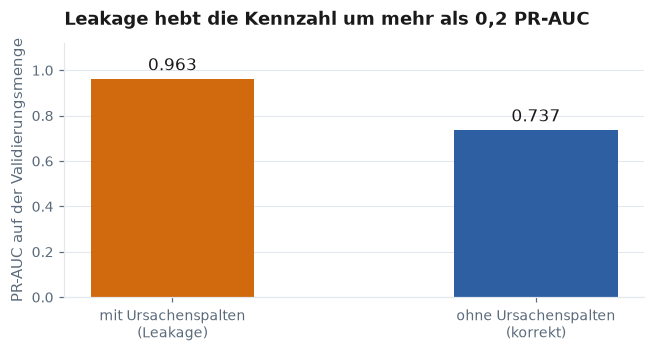

In [4]:
fig, ax = plt.subplots(figsize=(6.8, 3.0))

positionen = [0, 1]
werte = vergleich["PR-AUC"].to_numpy()
farben = [FARBEN["ausfall"], FARBEN["kein_ausfall"]]

ax.bar(positionen, werte, width=0.45, color=farben)
for pos, wert in zip(positionen, werte):
    ax.text(pos, wert + 0.02, f"{wert:.3f}", ha="center", va="bottom",
            fontsize=11, color=FARBEN["text"])

ax.set_xticks(positionen, ["mit Ursachenspalten\n(Leakage)", "ohne Ursachenspalten\n(korrekt)"])
ax.set_ylabel("PR-AUC auf der Validierungsmenge")
ax.set_ylim(0, 1.12)
ax.set_title("Leakage hebt die Kennzahl um mehr als 0,2 PR-AUC", loc="left")
nur_y_gitter(ax)

speichere(fig, "08_leakage_vergleich")
plt.show()

Mit den Ursachenspalten erreicht dasselbe Modell **0,963 statt 0,738** PR-AUC —
ein Unterschied von mehr als 0,2, allein durch fünf Spalten. Noch deutlicher ist
die **Precision von 1,000**: jede einzelne Alarmmeldung trifft zu. Ein Modell,
das auf realen Prozessgrößen beruht, erreicht so etwas nicht; solche Werte sind
kein Erfolg, sondern ein Warnzeichen.

Genau das ist die Tücke von Data Leakage: nichts stürzt ab, keine Warnung
erscheint, die Kennzahlen werden nur unrealistisch gut. Wer diesen Vergleich
nicht macht, merkt es erst im Betrieb — wenn das Modell die Ursachenspalten
nicht mehr bekommt und plötzlich nichts mehr trifft.

Ab hier wird ausschließlich mit dem Merkmalssatz **ohne** Ursachenspalten
weitergearbeitet.

## 3 Die Aufteilung

**Drei Teile, nicht zwei:**

* **Training** (70 %) — daraus lernt das Modell.
* **Validierung** (15 %) — damit werden Modell, Hyperparameter und
  Entscheidungsschwelle ausgewählt.
* **Test** (15 %) — wird **einmal** ganz am Ende angefasst.

`stratify` sorgt dafür, dass die seltene Klasse in allen drei Teilen im gleichen
Verhältnis vorkommt. Ohne das könnte die Testmenge zufällig kaum Ausfälle
enthalten, und jede Kennzahl darauf wäre Rauschen.

Aufgeteilt wird in zwei Schritten: erst die Testmenge abtrennen, dann aus dem
Rest die Validierungsmenge. Der zweite Anteil wird dabei auf den verbleibenden
Rest umgerechnet, damit beide am Ende 15 % des Gesamtdatensatzes ausmachen.

In [5]:
train, val, test = split_data(merkmale, params)

tabelle = uebersicht({"train": train, "val": val, "test": test}, ziel)
tabelle.round(4)

,Zeilen,Anteil,Ausfälle,Ausfallrate
Teilmenge,,,,
train,7000,0.70,237,0.0339
val,1500,0.15,51,0.0340
test,1500,0.15,51,0.0340


Die Ausfallrate liegt in allen drei Teilmengen bei 3,4 % — die Schichtung hat
gegriffen. Die Testmenge enthält 51 Ausfälle; das ist wenig, aber genug für eine
belastbare Endmessung, und es ist der Preis dafür, dass Training und Validierung
groß genug bleiben.

## 4 Kontrolle

Drei Dinge, die man besser prüft als annimmt.

In [6]:
# 1) Keine Zeile darf in zwei Teilmengen liegen.
indizes = {"train": set(train.index), "val": set(val.index), "test": set(test.index)}
ueberschneidungen = {
    f"{a} ∩ {b}": len(indizes[a] & indizes[b])
    for a, b in [("train", "val"), ("train", "test"), ("val", "test")]
}
print("Überschneidungen:", ueberschneidungen)

# 2) Zusammen müssen alle Zeilen wieder da sein.
print("Summe der Teilmengen:", len(train) + len(val) + len(test), "von", len(merkmale))

# 3) Keine Ursachenspalte darf sich eingeschlichen haben.
verbotene = set(params["data"]["leakage_columns"]) | set(params["data"]["id_columns"])
gefunden = verbotene & set(train.columns)
print("verbotene Spalten in den Teilmengen:", gefunden or "keine")

assert not any(ueberschneidungen.values()), "Teilmengen überschneiden sich!"
assert len(train) + len(val) + len(test) == len(merkmale), "Zeilen verloren gegangen!"
assert not gefunden, "Leakage-Spalte in den Teilmengen!"
print("\nAlle Kontrollen bestanden.")

Überschneidungen: {'train ∩ val': 0, 'train ∩ test': 0, 'val ∩ test': 0}
Summe der Teilmengen: 10000 von 10000
verbotene Spalten in den Teilmengen: keine

Alle Kontrollen bestanden.


Die drei `assert`-Zeilen sind bewusst gesetzt: Sie machen aus einer Sichtprüfung
eine ausführbare Zusicherung. Geht bei einer späteren Änderung etwas schief,
bricht dieses Notebook ab, statt stillschweigend falsche Teilmengen zu erzeugen.

## 5 Ablage

Gespeichert wird als Parquet statt CSV: Datentypen bleiben erhalten. Aus einer
CSV gelesen wäre `type` wieder beliebiger Text, und Ganzzahlen könnten als
Fließkommazahlen zurückkommen.

Die Dateien liegen in `data/processed/` und sind — wie alle abgeleiteten Daten —
von der Versionsverwaltung ausgenommen. Sie lassen sich jederzeit aus den
Rohdaten neu erzeugen, deshalb gehören sie nicht ins Git.

In [7]:
pfade = schreibe_teilmengen({"train": train, "val": val, "test": test})
for name, pfad in pfade.items():
    print(f"{name:6s} -> {pfad.relative_to(pfad.parents[2])}  ({pfad.stat().st_size / 1024:.0f} KB)")

train  -> data/processed/train.parquet  (50 KB)
val    -> data/processed/val.parquet  (18 KB)
test   -> data/processed/test.parquet  (18 KB)


## Die Regel, ab jetzt

> **Die Testmenge wird nicht angeschaut.** Nicht zum „kurz Prüfen", nicht zum
> Feinjustieren der Entscheidungsschwelle, nicht zum Vergleichen von Modellen.
> Jede Entscheidung, die auf der Testmenge beruht, macht deren Kennzahl zu einer
> optimistischen Lüge.

Modellauswahl, Hyperparameter und Schwellenwert werden ausschließlich auf der
**Validierungsmenge** entschieden. Die Testmenge wird in Etappe 12 genau einmal
angefasst.

---

## Zusammenfassung

| | |
|---|---|
| Entfernt | `TWF, HDF, PWF, OSF, RNF` (Leakage), `udi, product_id` (Kennungen) |
| Belegt | PR-AUC 0,963 mit gegenüber 0,738 ohne Ursachenspalten |
| Aufteilung | 70 / 15 / 15, geschichtet nach der Zielklasse, `random_state=42` |
| Klassenverhältnis | 3,4 % in allen drei Teilmengen |
| Abgelegt | `data/processed/{train,val,test}.parquet` |

Als Nächstes: Etappe 7 — eine bewusst einfache Baseline als Messlatte, gegen die
sich jedes komplexere Modell rechtfertigen muss.